In [137]:
import torch
import torch.nn as nn
import torch.optim as optimizer
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [138]:
import pandas as pd

def function(x):
    y = np.exp(np.sin(x)) * np.cos(x**2) + np.log(abs(x) + 1)
    return y


def cal_data(path, num):
    np.random.seed(num)
    x = np.random.uniform(-5,5,num)
    y = [function(i) for i in x]

    df = pd.DataFrame({
        "x":x,
        "y":y
    })
    df.to_csv(path, index=False)


train_path = "train.csv"
test_path = "test.csv"

cal_data(train_path, 10000)
cal_data(test_path, 2000)


In [139]:
import os
import pandas as pd
from torch.utils.data import Dataset


class MyDataset(Dataset):
    def __init__(self, path=train_path):
        self.data = pd.read_csv(f"{path}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data.iloc[idx, 0]
        y = self.data.iloc[idx, 1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)



train = MyDataset(path=train_path)
test = MyDataset(path=test_path)

print(f"Dataset size: {len(train)}, {len(test)}")
train[10], test[10]

Dataset size: 10000, 2000


((tensor(0.3296), tensor(1.6589)), (tensor(-3.4788), tensor(2.7442)))

In [140]:
from torch.utils.data import DataLoader

batch_size = 128

train_dataloader = DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test, batch_size=batch_size, shuffle=False, num_workers=0)

x,y = next(iter(train_dataloader))
print(x[0], y.shape)
x,y = next(iter(train_dataloader))
print(x[0], y.shape)

tensor(-3.1790) torch.Size([128])
tensor(3.0968) torch.Size([128])


In [141]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, **kwargs):
        super(MLP, self).__init__(**kwargs)
        self.hidden = nn.Linear(1, 64)
        self.act = nn.ReLU()
        self.output = nn.Linear(64, 1)

        self.mlp = nn.Sequential(
            nn.Linear(1, 512),
            nn.Tanh(),
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        # x = self.hidden(x)
        # x = self.act(x)
        # x = self.output(x)
        x = self.mlp(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP().to(device)
x = torch.rand(4,1).to(device)
print(model,model(x))

# params = list(model.parameters())
# for param in params:
#     print(param.shape)


MLP(
  (hidden): Linear(in_features=1, out_features=64, bias=True)
  (act): ReLU()
  (output): Linear(in_features=64, out_features=1, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=1, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): Tanh()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): Tanh()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): Tanh()
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): Tanh()
    (10): Linear(in_features=512, out_features=1, bias=True)
  )
) tensor([[0.0393],
        [0.0367],
        [0.0411],
        [0.0311]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [142]:
from tqdm import tqdm

def train(epoch):
    model.train()
    train_loss = 0

    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")

    for x,y in pbar:
        x,y = x.to(device), y.to(device)
        x = x.view(-1,1)
        y = y.view(-1,1)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        train_loss += loss.item() * x.size(0)
    train_loss /= len(train_dataloader.dataset)
    pbar.set_description(f"Epoch {epoch+1}/{epochs} - Train loss: {train_loss:.4f}")
    pbar.close()

def val(epoch):
    model.eval()
    eval_loss = 0
    pbar = tqdm(test_dataloader,desc=f"Epoch {epoch+1}/{epochs}")

    with torch.no_grad():
        for x,y in pbar:
            x,y = x.to(device), y.to(device)
            x = x.view(-1,1)
            y = y.view(-1,1)
            output = model(x)
            loss = criterion(output, y)
            eval_loss += loss.item() * x.size(0)
    eval_loss /= len(test_dataloader.dataset)
    pbar.set_description(f"Epoch {epoch+1}/{epochs} - Eval loss: {eval_loss:.4f}")
    pbar.close()



In [143]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

epochs = 200
learn_rate = 0.0001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learn_rate)


for epoch in range(epochs):
    train(epoch)
    val(epoch)
torch.save(model.state_dict(),"model.pth")

Epoch 200/200: 100%|██████████| 16/16 [00:00<00:00, 304.75it/s]


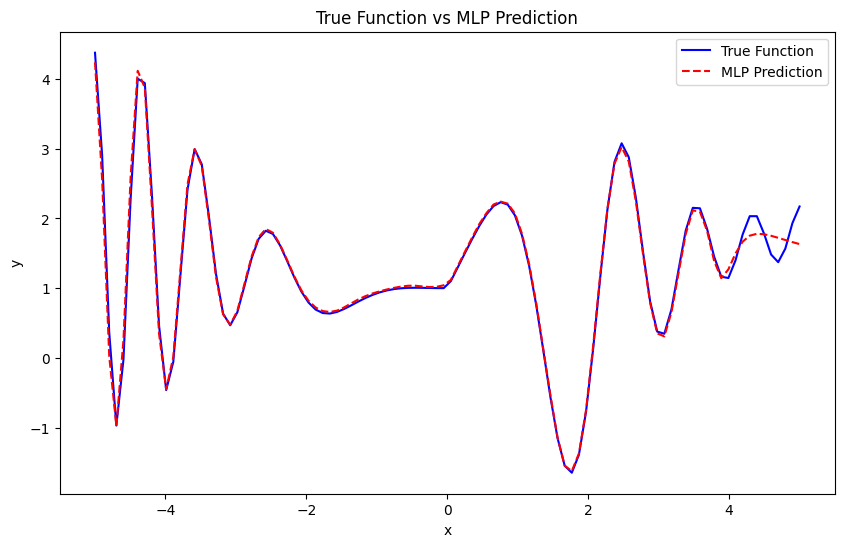

In [144]:
model = MLP().to(device)
model_state_dict = torch.load("model.pth")
model.load_state_dict(model_state_dict)
x = torch.linspace(-5,5,100)
y = function(x.numpy())

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(x.numpy(), y, label="True Function", color="blue")

model.eval()
with torch.no_grad():
    x2 = x.clone().view(-1,1).to(device)
    pred_tensor = model(x2)
    pred = pred_tensor.cpu().view(-1).numpy()

plt.plot(x.numpy(), pred, label="MLP Prediction", color="red", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("True Function vs MLP Prediction")
plt.show()